   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.8 MB/s eta 0:00:00
Repo cloned at: /content/Data-Visualization-in-Python
Found repo CSV: /content/Data-Visualization-in-Python/data/cancer.csv
Repo dataset shape: (569, 31)

Main DF for Matplotlib/Seaborn quick demos: repo:cancer.csv | shape: (569, 31)

=== Matplotlib (static) ===


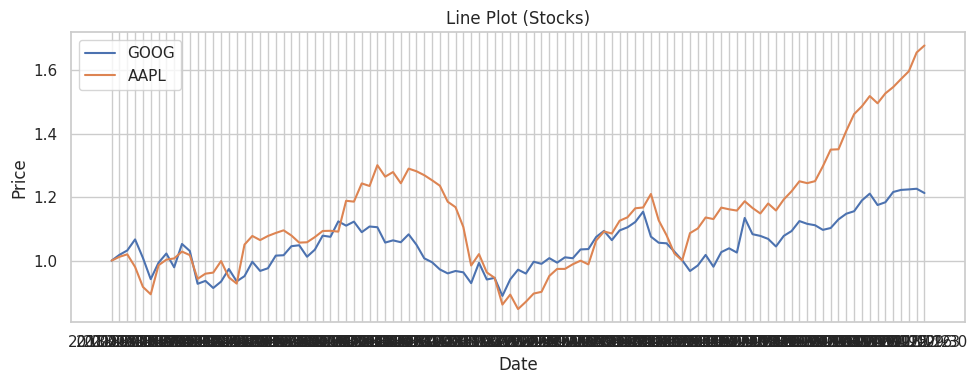

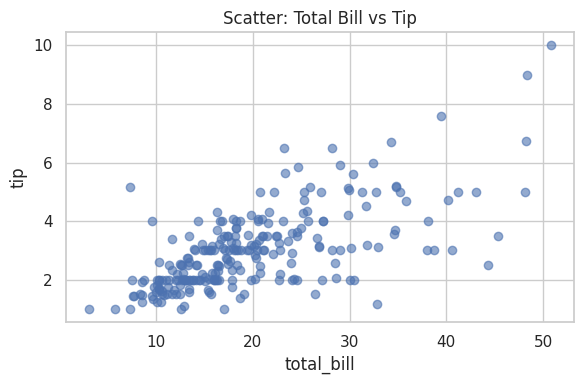

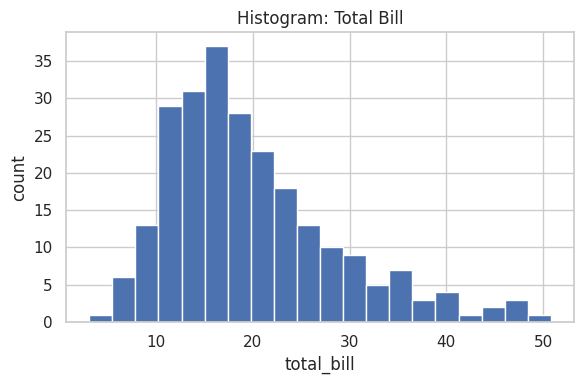

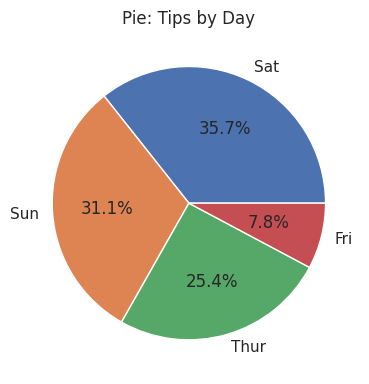

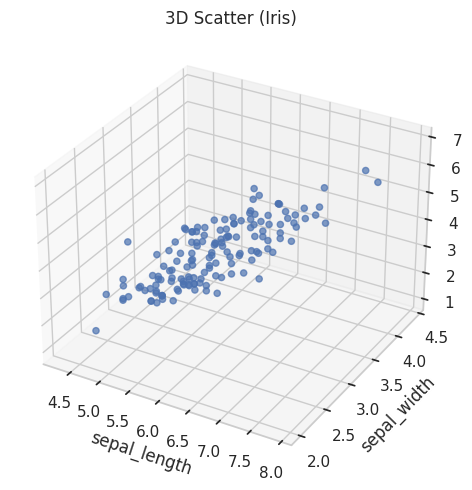


=== Seaborn (statistical) ===


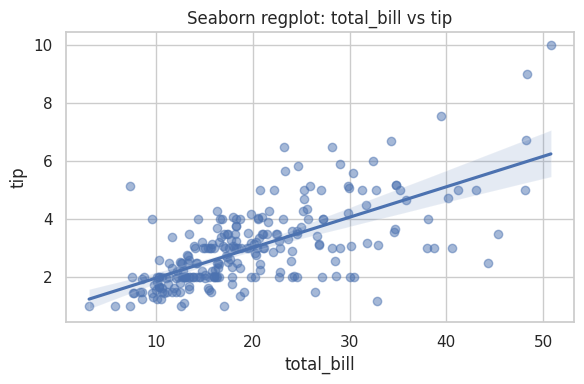

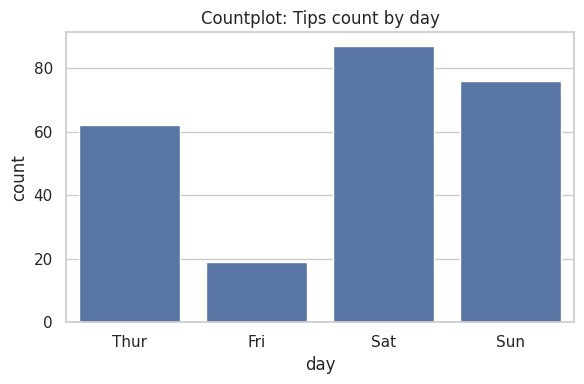

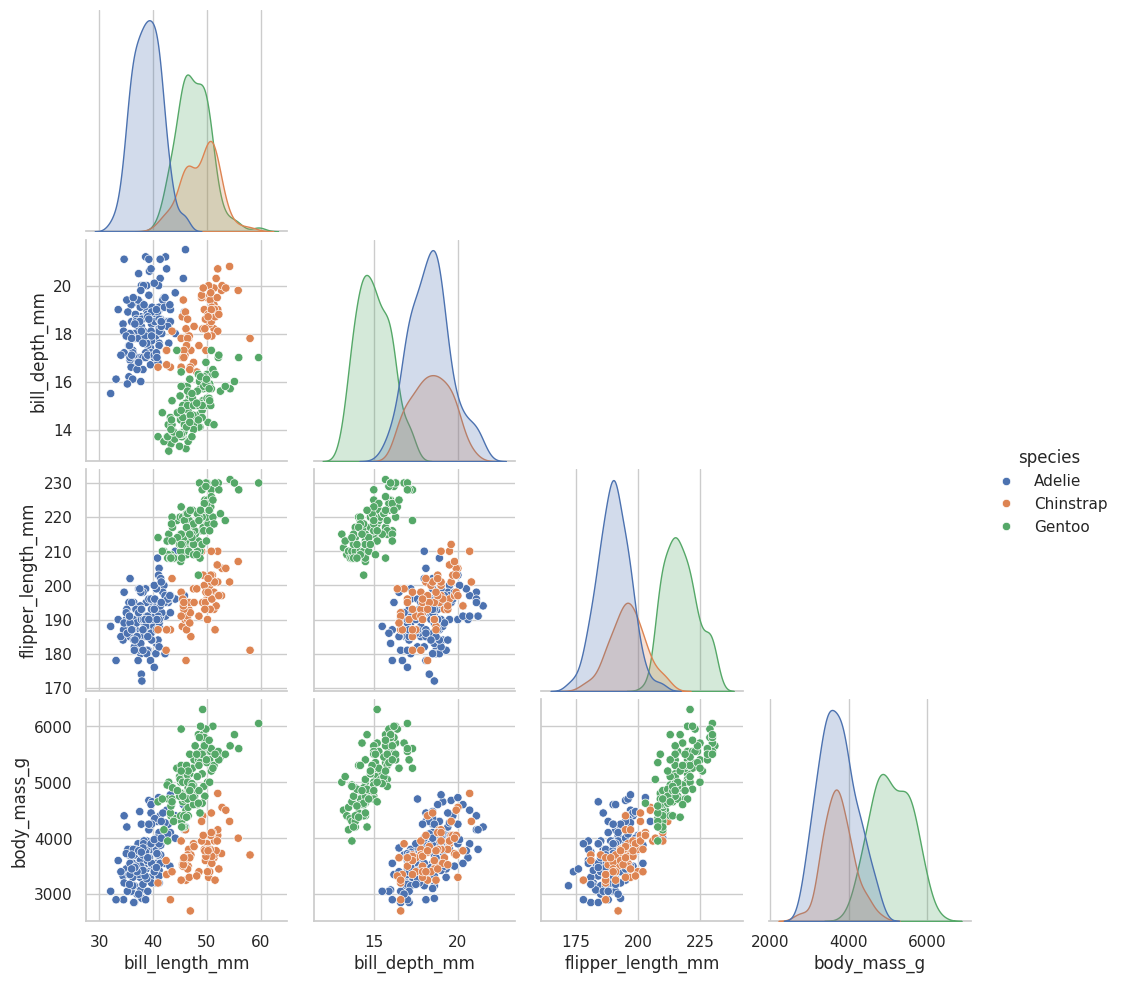

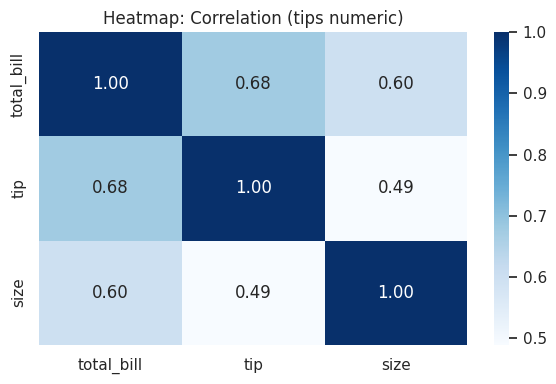

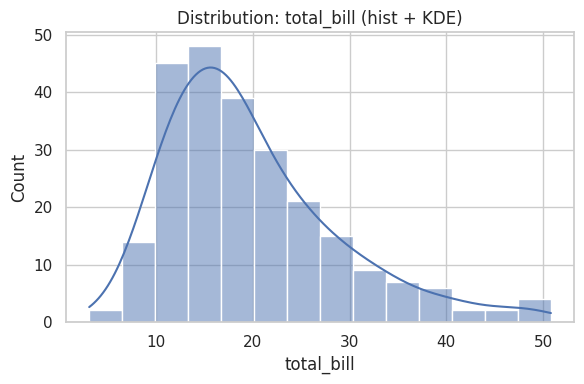


=== Plotly (interactive) ===



=== Altair (declarative) ===


alt.Chart(...)

In [ ]:
# ============================
# COLAB: Data Visualization Mini-Portfolio (Matplotlib + Seaborn + Plotly + Altair)
# Source repo (for your memo): https://github.com/kanchanchy/Data-Visualization-in-Python
# ============================

# --- Install/upgrade deps (safe in Colab) ---
!pip -q install --upgrade seaborn plotly altair vega_datasets kaleido

# --- Imports ---
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import altair as alt
from vega_datasets import data as vega_data

# --- Clone the GitHub project (optional, but included since you asked for a GitHub project) ---
REPO_URL = "https://github.com/kanchanchy/Data-Visualization-in-Python.git"
REPO_DIR = Path("/content/Data-Visualization-in-Python")

if not REPO_DIR.exists():
    !git clone -q {REPO_URL} {REPO_DIR}

print("Repo cloned at:", REPO_DIR)

# --- Try to load a dataset from the repo if any exists, else fallback to built-in datasets ---
data_dir = REPO_DIR / "data"
csv_candidates = []
if data_dir.exists():
    csv_candidates = list(data_dir.rglob("*.csv")) + list(data_dir.rglob("*.CSV"))

df_repo = None
if csv_candidates:
    chosen_csv = sorted(csv_candidates, key=lambda p: p.name.lower())[0]
    print("Found repo CSV:", chosen_csv)
    try:
        df_repo = pd.read_csv(chosen_csv)
        print("Repo dataset shape:", df_repo.shape)
    except Exception as e:
        print("Could not read repo CSV, fallback will be used. Error:", e)

# Fallback datasets (reliable in Colab)
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")                # nice for categorical + distributions
penguins = sns.load_dataset("penguins").dropna()
iris = px.data.iris()                          # classic
gapminder = px.data.gapminder()                # plotly classic
cars = px.data.carshare()                      # time-ish
stocks = px.data.stocks()                      # lines

# Helper: choose a "main" df to show basic EDA, prefer repo df if it looks usable
def pick_main_df():
    if df_repo is not None and df_repo.shape[0] >= 20:
        # If repo df has too many non-numeric columns, still fine; we’ll just demo basic plots safely.
        return df_repo.copy(), f"repo:{chosen_csv.name}"
    return tips.copy(), "seaborn:tips"

df, df_name = pick_main_df()
print("\nMain DF for Matplotlib/Seaborn quick demos:", df_name, "| shape:", df.shape)

# ============================
# 1) MATPLOTLIB (static)
# ============================
print("\n=== Matplotlib (static) ===")

# 1A: Basic line plot (using stocks dataset)
plt.figure(figsize=(10,4))
plt.plot(stocks["date"], stocks["GOOG"], label="GOOG")
plt.plot(stocks["date"], stocks["AAPL"], label="AAPL")
plt.title("Line Plot (Stocks)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

# 1B: Scatter plot (tips)
plt.figure(figsize=(6,4))
plt.scatter(tips["total_bill"], tips["tip"], alpha=0.6)
plt.title("Scatter: Total Bill vs Tip")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.tight_layout()
plt.show()

# 1C: Histogram (tips)
plt.figure(figsize=(6,4))
plt.hist(tips["total_bill"], bins=20)
plt.title("Histogram: Total Bill")
plt.xlabel("total_bill")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 1D: Pie chart (tips day distribution)
day_counts = tips["day"].value_counts()
plt.figure(figsize=(6,4))
plt.pie(day_counts.values, labels=day_counts.index, autopct="%1.1f%%")
plt.title("Pie: Tips by Day")
plt.tight_layout()
plt.show()

# 1E: 3D scatter (iris)
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    iris["sepal_length"],
    iris["sepal_width"],
    iris["petal_length"],
    alpha=0.7
)
ax.set_title("3D Scatter (Iris)")
ax.set_xlabel("sepal_length")
ax.set_ylabel("sepal_width")
ax.set_zlabel("petal_length")
plt.tight_layout()
plt.show()

# ============================
# 2) SEABORN (statistical)
# ============================
print("\n=== Seaborn (statistical) ===")

# 2A: Scatter + regression
plt.figure(figsize=(6,4))
sns.regplot(data=tips, x="total_bill", y="tip", scatter_kws={"alpha":0.5})
plt.title("Seaborn regplot: total_bill vs tip")
plt.tight_layout()
plt.show()

# 2B: Count plot
plt.figure(figsize=(6,4))
sns.countplot(data=tips, x="day")
plt.title("Countplot: Tips count by day")
plt.tight_layout()
plt.show()

# 2C: Pairplot (penguins)
sns.pairplot(penguins, hue="species", corner=True)
plt.show()

# 2D: Heatmap / correlation
num_cols = tips.select_dtypes(include=np.number)
plt.figure(figsize=(6,4))
sns.heatmap(num_cols.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap: Correlation (tips numeric)")
plt.tight_layout()
plt.show()

# 2E: Distribution (KDE + histogram)
plt.figure(figsize=(6,4))
sns.histplot(data=tips, x="total_bill", kde=True)
plt.title("Distribution: total_bill (hist + KDE)")
plt.tight_layout()
plt.show()

# ============================
# 3) PLOTLY EXPRESS (interactive)
# ============================
print("\n=== Plotly (interactive) ===")

# 3A: Interactive scatter (gapminder)
fig = px.scatter(
    gapminder.query("year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    title="Interactive Scatter (Gapminder 2007): GDP per Capita vs Life Expectancy"
)
fig.show()

# 3B: Bubble over time (gapminder)
fig = px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    animation_frame="year",
    animation_group="country",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    range_y=[20, 90],
    title="Animated Bubble Chart (Gapminder): GDP vs LifeExp over time"
)
fig.show()

# 3C: Interactive line (stocks)
fig = px.line(stocks, x="date", y=["GOOG", "AAPL", "AMZN"], title="Interactive Line: Stocks")
fig.show()

# 3D: Interactive bar (tips)
fig = px.bar(
    tips.groupby(["day","time"], as_index=False)["total_bill"].mean(),
    x="day", y="total_bill", color="time", barmode="group",
    title="Bar: Avg total_bill by day and time"
)
fig.show()

# 3E: Interactive pie (tips)
fig = px.pie(tips, names="day", title="Pie: tips records by day")
fig.show()

# 3F: Sunburst (gapminder 2007)
gm2007 = gapminder.query("year == 2007").copy()
gm2007["pop_m"] = gm2007["pop"] / 1e6
fig = px.sunburst(
    gm2007,
    path=["continent", "country"],
    values="pop_m",
    title="Sunburst: Population (millions) by Continent → Country (2007)"
)
fig.show()

# 3G: Gantt / Timeline (synthetic tasks)
tasks = pd.DataFrame({
    "Task": ["Collect Data", "Clean Data", "EDA", "Modeling", "Report"],
    "Start": pd.to_datetime(["2026-01-01","2026-01-03","2026-01-05","2026-01-08","2026-01-11"]),
    "Finish": pd.to_datetime(["2026-01-03","2026-01-05","2026-01-08","2026-01-11","2026-01-14"]),
    "Owner": ["You","You","You","You","You"]
})
fig = px.timeline(tasks, x_start="Start", x_end="Finish", y="Task", color="Owner", title="Gantt (Timeline): Mini Project Plan")
fig.update_yaxes(autorange="reversed")
fig.show()

# ============================
# 4) ALTAIR (declarative)
# ============================
print("\n=== Altair (declarative) ===")

cars_alt = vega_data.cars()
chart = (
    alt.Chart(cars_alt)
    .mark_circle()
    .encode(
        x=alt.X("Horsepower:Q", scale=alt.Scale(zero=False)),
        y=alt.Y("Miles_per_Gallon:Q", scale=alt.Scale(zero=False)),
        color="Origin:N",
        tooltip=["Name:N","Origin:N","Horsepower:Q","Miles_per_Gallon:Q"]
    )
    .properties(title="Altair: Horsepower vs MPG (with tooltips)", width=700, height=400)
    .interactive()
)
chart




---



# Portfolio Overview

> **Goal:** demonstrate core + modern visualization techniques in a structured way (with explanations).

**Case Studies:**
1) *Restaurant tipping behavior* (Seaborn dataset) → exploratory analysis & statistical plots.
2) *Global development trends* (Gapminder via Plotly) → interactive + storytelling visuals.
3) *Interactive cross-filter dashboard* (Altair) → modern exploratory workflow.
4) *Advanced visuals* (Sankey, Parallel Coordinates, Choropleth, Small Multiples) → portfolio-grade variety.

## Load datasets

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4


...

> **Why:** raw columns are often not enough. We create interpretable features that help explain patterns.

Examples:
- Tip rate (%) makes comparisons fair across different bill sizes.
- Bill buckets simplify distribution comparisons.
- Weekend flag helps segmentation.

,total_bill,tip,sex,smoker,day,time,size,tip_rate,is_weekend,bill_bucket
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,True,10–20
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,True,10–20
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,True,20–35
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,True,20–35
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,True,20–35


## Section C — Core Visualization Techniques (with purpose)

### C1) Distribution — Histogram + KDE

> **Why:** reveals shape (skew), spread, and outliers. KDE adds a smooth view of the distribution.

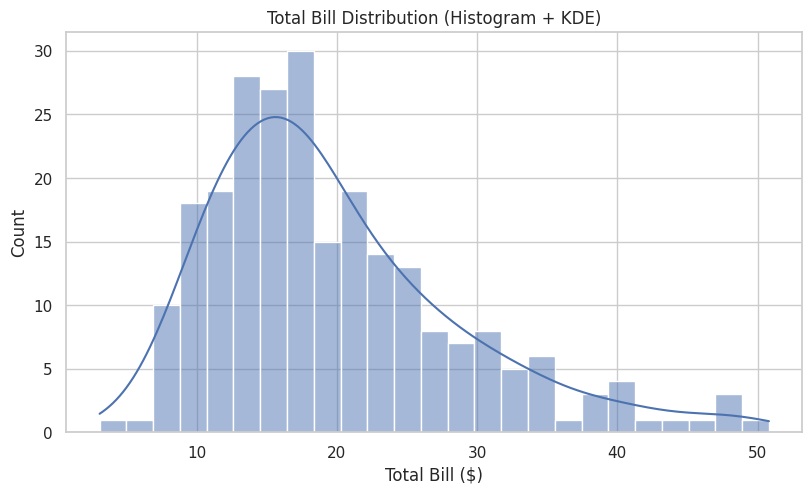

### C2) Relationship — Scatter + Regression Line

> **Why:** shows association between variables. Regression line helps read the *direction* of the relationship.

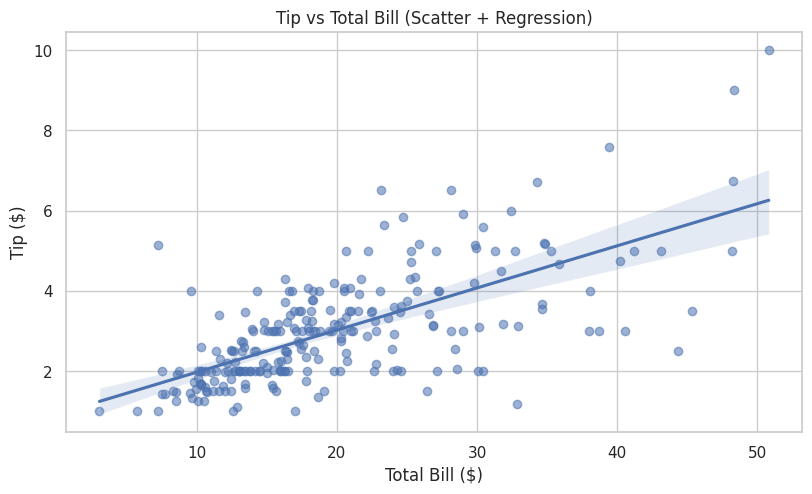

### C3) Comparison — Box Plot + Swarm Overlay

> **Why:** box shows summary + outliers; swarm shows *actual points* (modern best practice for transparency).

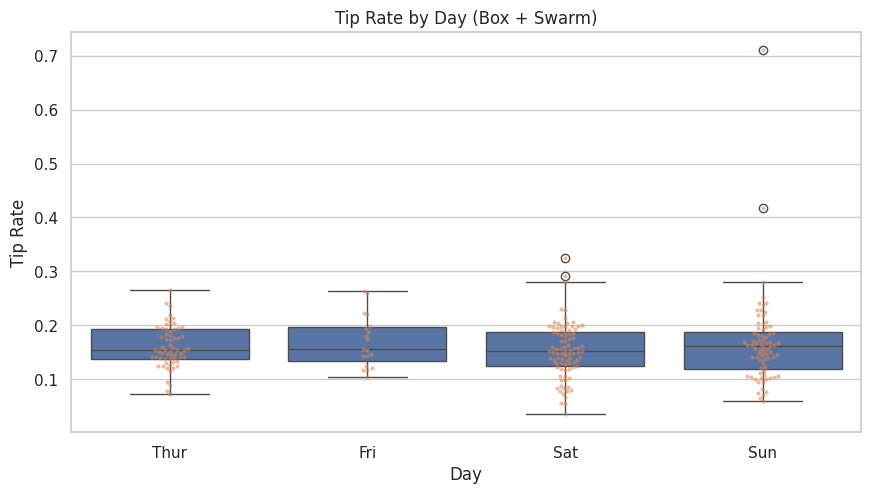

### C4) Category Breakdown — Bar Plot with Uncertainty

> **Why:** summarizes differences between groups. Seaborn bars (by default) convey uncertainty (confidence intervals).

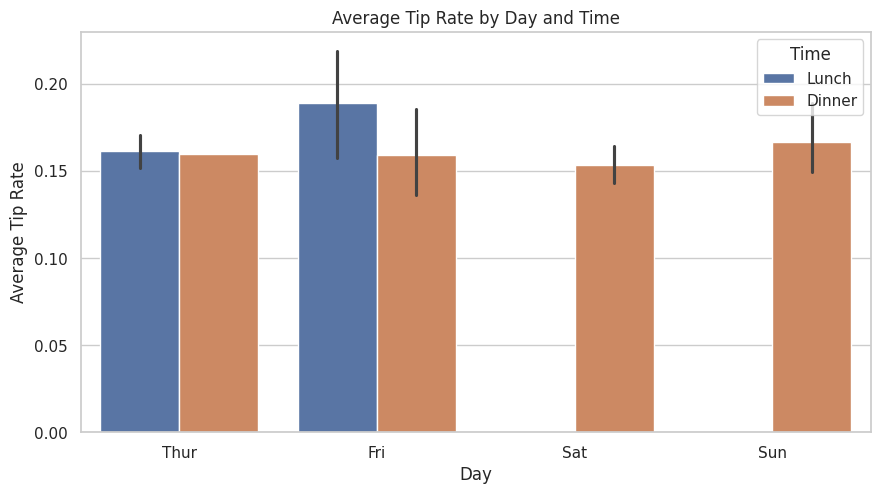

### C5) Correlation — Heatmap

> **Why:** quick scan for which numeric variables move together (useful before modeling or feature selection).

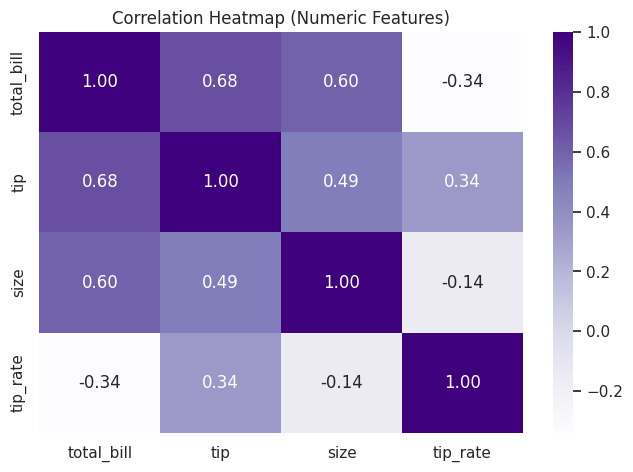

## Section D — Modern Interactive Visuals (Plotly)

### D1) Interactive Scatter with Rich Hover

> **Why:** interactive hover lets viewers explore details without cluttering the chart.

### D2) Small Multiples (Faceting) — Patterns by Group

> **Why:** small multiples compare many subgroups without mixing everything into one confusing plot.

...

> **Why:** Sankey is modern and memorable for showing flows (funnels, transitions, allocations).
Here: a simple flow from 'Day' → 'Time' → 'Smoker' using counts.

### E2) Parallel Coordinates (Multivariate Pattern Reading)

> **Why:** parallel coordinates help compare many variables at once (useful for clustering intuition & outliers).

## Section F — Modern Interactive Dashboard (Altair Cross-Filtering)

> **Why this is modern:** cross-filtering is a common technique in dashboards.
Users can click a group to filter other charts (explore patterns fast).

In [ ]:
# ============================================================
# 📒 DATA VISUALIZATION + ANALYSIS PORTFOLIO (Colab One-Cell)
# A beginner-friendly, polished, modern mini-portfolio notebook.
# Includes: clean structure + WHY each technique is used + consistent colors.
# Tools: Pandas + Matplotlib + Seaborn + Plotly + Altair (interactive, modern)
# ============================================================

# -----------------------------
# 0) Install + Imports
# -----------------------------
!pip -q install --upgrade seaborn plotly altair vega_datasets kaleido

import warnings, math, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import cycler
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import altair as alt
from vega_datasets import data as vega_data

from IPython.display import display, Markdown, HTML

# -----------------------------
# 1) Portfolio Styling (Consistency)
# -----------------------------
def md(title: str, level: int = 2):
    display(Markdown(f"{'#'*level} {title}"))

def note(text: str):
    display(Markdown(f"> {text}"))

def spacer():
    display(HTML("<hr style='border: 0; height: 1px; background: #e8e8e8; margin: 18px 0;'>"))

# Consistent color system (one palette used everywhere)
PALETTE = {
    "primary":  "#6C5CE7",  # purple
    "accent":   "#00B894",  # teal/green
    "warn":     "#E17055",  # orange
    "info":     "#0984E3",  # blue
    "neutral":  "#2D3436",  # dark
    "light":    "#F7F7FB"   # background-ish
}
COLORWAY = [PALETTE["primary"], PALETTE["accent"], PALETTE["info"], PALETTE["warn"], "#A29BFE", "#55EFC4"]

# Matplotlib global look
plt.rcParams.update({
    "figure.figsize": (9.5, 5.2),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.edgecolor": "#D0D0D0",
    "axes.linewidth": 0.9,
    "grid.color": "#E6E6EE",
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
    "axes.grid": True,
    "font.family": "DejaVu Sans",
    "axes.prop_cycle": cycler(color=COLORWAY)
})
sns.set_theme(style="whitegrid")

# Plotly global look
px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = COLORWAY

# Altair theme (clean + consistent)
alt.data_transformers.disable_max_rows()

def altair_theme():
    return {
        "config": {
            "background": "white",
            "title": {"fontSize": 16, "font": "DejaVu Sans", "color": PALETTE["neutral"]},
            "axis": {
                "labelFontSize": 11,
                "titleFontSize": 12,
                "gridColor": "#E6E6EE",
                "domainColor": "#D0D0D0",
                "labelColor": PALETTE["neutral"],
                "titleColor": PALETTE["neutral"],
            },
            "legend": {"labelFontSize": 11, "titleFontSize": 12},
            "range": {"category": COLORWAY}
        }
    }

alt.themes.register("portfolio_theme", altair_theme)
alt.themes.enable("portfolio_theme")

# -----------------------------
# 2) Load Data (Meaningful + Reliable)
# -----------------------------
md("Portfolio Overview", 1)
note(
    "**Goal:** demonstrate core + modern visualization techniques in a structured way (with explanations).\n\n"
    "**Case Studies:**\n"
    "1) *Restaurant tipping behavior* (Seaborn dataset) → exploratory analysis & statistical plots.\n"
    "2) *Global development trends* (Gapminder via Plotly) → interactive + storytelling visuals.\n"
    "3) *Interactive cross-filter dashboard* (Altair) → modern exploratory workflow.\n"
    "4) *Advanced visuals* (Sankey, Parallel Coordinates, Choropleth, Small Multiples) → portfolio-grade variety."
)

md("Load datasets")
tips = sns.load_dataset("tips")  # restaurants dataset
penguins = sns.load_dataset("penguins").dropna()
gapminder = px.data.gapminder()  # global data
cars = vega_data.cars()          # altair-friendly dataset

display(tips.head(3))
display(gapminder.head(3))

# -----------------------------
# 3) Data Quality Checks (Analysis skill)
# -----------------------------
md("Section A — Data Quality & Basic Profiling")
note("**Why this matters:** good visuals start with clean, trustworthy data. Here we check missing values, types, and simple sanity constraints.")

def profile(df: pd.DataFrame, name: str):
    print(f"\n--- Profile: {name} ---")
    display(df.sample(5, random_state=7))
    print("\nShape:", df.shape)
    print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False).head(10))
    print("\nDtypes:\n", df.dtypes)

profile(tips, "tips")
spacer()

# -----------------------------
# 4) Feature Engineering (Meaningful)
# -----------------------------
md("Section B — Feature Engineering (to make visuals more insightful)")
note(
    "**Why:** raw columns are often not enough. We create interpretable features that help explain patterns.\n\n"
    "Examples:\n"
    "- Tip rate (%) makes comparisons fair across different bill sizes.\n"
    "- Bill buckets simplify distribution comparisons.\n"
    "- Weekend flag helps segmentation."
)

df = tips.copy()
df["tip_rate"] = df["tip"] / df["total_bill"]  # fairness metric
df["is_weekend"] = df["day"].isin(["Sat", "Sun"])
df["bill_bucket"] = pd.cut(df["total_bill"], bins=[0, 10, 20, 35, 60], labels=["0–10", "10–20", "20–35", "35–60"], include_lowest=True)

display(df.head(5))

# -----------------------------
# 5) Core Visualization Techniques (with WHY)
# -----------------------------
md("Section C — Core Visualization Techniques (with purpose)")

# C1) Distribution: Histogram + KDE
md("C1) Distribution — Histogram + KDE", 3)
note("**Why:** reveals shape (skew), spread, and outliers. KDE adds a smooth view of the distribution.")
plt.figure(figsize=(9.5, 5.2))
sns.histplot(df["total_bill"], kde=True, bins=25)
plt.title("Total Bill Distribution (Histogram + KDE)")
plt.xlabel("Total Bill ($)")
plt.ylabel("Count")
plt.show()
spacer()

# C2) Relationship: Scatter + trend
md("C2) Relationship — Scatter + Regression Line", 3)
note("**Why:** shows association between variables. Regression line helps read the *direction* of the relationship.")
plt.figure(figsize=(9.5, 5.2))
sns.regplot(data=df, x="total_bill", y="tip", scatter_kws={"alpha": 0.55})
plt.title("Tip vs Total Bill (Scatter + Regression)")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()
spacer()

# C3) Comparison: Box + Swarm (modern combo)
md("C3) Comparison — Box Plot + Swarm Overlay", 3)
note("**Why:** box shows summary + outliers; swarm shows *actual points* (modern best practice for transparency).")
plt.figure(figsize=(10.2, 5.2))
sns.boxplot(data=df, x="day", y="tip_rate")
sns.swarmplot(data=df, x="day", y="tip_rate", size=3, alpha=0.55)
plt.title("Tip Rate by Day (Box + Swarm)")
plt.xlabel("Day")
plt.ylabel("Tip Rate")
plt.show()
spacer()

# C4) Category breakdown: Bar (with CI)
md("C4) Category Breakdown — Bar Plot with Uncertainty", 3)
note("**Why:** summarizes differences between groups. Seaborn bars (by default) convey uncertainty (confidence intervals).")
plt.figure(figsize=(10.2, 5.2))
sns.barplot(data=df, x="day", y="tip_rate", hue="time")
plt.title("Average Tip Rate by Day and Time")
plt.xlabel("Day")
plt.ylabel("Average Tip Rate")
plt.legend(title="Time", loc="upper right")
plt.show()
spacer()

# C5) Correlation: Heatmap
md("C5) Correlation — Heatmap", 3)
note("**Why:** quick scan for which numeric variables move together (useful before modeling or feature selection).")
num = df[["total_bill", "tip", "size", "tip_rate"]].corr()
plt.figure(figsize=(7.8, 5.2))
sns.heatmap(num, annot=True, fmt=".2f", cmap="Purples")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()
spacer()

# -----------------------------
# 6) Modern Interactive Visuals (Plotly) + Storytelling
# -----------------------------
md("Section D — Modern Interactive Visuals (Plotly)")

md("D1) Interactive Scatter with Rich Hover", 3)
note("**Why:** interactive hover lets viewers explore details without cluttering the chart.")
fig = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="day",
    symbol="time",
    hover_data=["sex", "smoker", "size", "tip_rate"],
    title="Interactive: Tips vs Total Bill (hover to explore)"
)
fig.update_layout(title_x=0.01)
fig.show()
spacer()

md("D2) Small Multiples (Faceting) — Patterns by Group", 3)
note("**Why:** small multiples compare many subgroups without mixing everything into one confusing plot.")
fig = px.histogram(
    df,
    x="tip_rate",
    color="time",
    facet_col="day",
    facet_col_wrap=2,
    nbins=25,
    opacity=0.85,
    title="Small Multiples: Tip Rate Distribution by Day"
)
fig.update_layout(title_x=0.01)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()
spacer()

md("D3) Global Storytelling — Gapminder Bubble Chart", 3)
note(
    "**Why:** bubble charts (with size = population) are classic for communicating multi-dimensional stories.\n"
    "Here: GDP per capita vs life expectancy, colored by continent."
)
gm2007 = gapminder.query("year == 2007")
fig = px.scatter(
    gm2007,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=60,
    title="Gapminder 2007: GDP per Capita vs Life Expectancy (size = population)"
)
fig.update_layout(title_x=0.01)
fig.show()
spacer()

md("D4) Choropleth Map (Modern + High-Impact)", 3)
note("**Why:** maps communicate geographic patterns instantly. Useful for global indicators (life expectancy, GDP, etc.).")
fig = px.choropleth(
    gm2007,
    locations="iso_alpha",
    color="lifeExp",
    hover_name="country",
    color_continuous_scale="Purples",
    title="World Map: Life Expectancy (2007)"
)
fig.update_layout(title_x=0.01)
fig.show()
spacer()

# -----------------------------
# 7) Advanced / Portfolio-Grade Visuals
# -----------------------------
md("Section E — Advanced / Portfolio-Grade Visuals")

md("E1) Sankey Diagram (Flow Visualization)", 3)
note(
    "**Why:** Sankey is modern and memorable for showing flows (funnels, transitions, allocations).\n"
    "Here: a simple flow from 'Day' → 'Time' → 'Smoker' using counts."
)
flow = df.copy()
flow["smoker"] = flow["smoker"].astype(str)

# Build nodes
left = flow["day"].astype(str)
mid = flow["time"].astype(str)
right = flow["smoker"].astype(str)

nodes = pd.Index(pd.concat([left, mid, right]).unique())
node_map = {k: i for i, k in enumerate(nodes)}

# Build links (day->time, time->smoker)
links1 = flow.groupby(["day", "time"]).size().reset_index(name="value")
links2 = flow.groupby(["time", "smoker"]).size().reset_index(name="value")

source = [node_map[a] for a in links1["day"]] + [node_map[a] for a in links2["time"]]
target = [node_map[b] for b in links1["time"]] + [node_map[b] for b in links2["smoker"]]
value  = links1["value"].tolist() + links2["value"].tolist()

sankey = go.Figure(data=[go.Sankey(
    node=dict(label=nodes.tolist(), pad=12, thickness=14),
    link=dict(source=source, target=target, value=value)
)])
sankey.update_layout(title="Sankey: Day → Time → Smoker (counts)", title_x=0.01)
sankey.show()
spacer()

md("E2) Parallel Coordinates (Multivariate Pattern Reading)", 3)
note("**Why:** parallel coordinates help compare many variables at once (useful for clustering intuition & outliers).")
pc = px.parallel_coordinates(
    df,
    dimensions=["total_bill", "tip", "size", "tip_rate"],
    color=df["tip_rate"],
    color_continuous_scale=px.colors.sequential.Purples,
    title="Parallel Coordinates: Multi-Feature Patterns (colored by tip_rate)"
)
pc.update_layout(title_x=0.01)
pc.show()
spacer()

# -----------------------------
# 8) Modern Interactive Cross-Filter Dashboard (Altair)
# -----------------------------
md("Section F — Modern Interactive Dashboard (Altair Cross-Filtering)")
note(
    "**Why this is modern:** cross-filtering is a common technique in dashboards.\n"
    "Users can click a group to filter other charts (explore patterns fast)."
)

cars_df = cars.copy().dropna()
cars_df["Origin"] = cars_df["Origin"].astype(str)

selection = alt.selection_point(fields=["Origin"], bind="legend")

scatter = (
    alt.Chart(cars_df)
    .mark_circle(size=70, opacity=0.75)
    .encode(
        x=alt.X("Horsepower:Q", title="Horsepower"),
        y=alt.Y("Miles_per_Gallon:Q", title="Miles per Gallon"),
        color=alt.Color("Origin:N", title="Origin"),
        tooltip=["Name:N", "Origin:N", "Horsepower:Q", "Miles_per_Gallon:Q", "Weight_in_lbs:Q"]
    )
    .add_params(selection)
    .transform_filter(selection)
    .properties(title="Interactive Scatter (click legend to filter)", width=700, height=380)
)

bar = (
    alt.Chart(cars_df)
    .mark_bar(opacity=0.9)
    .encode(
        x=alt.X("Origin:N", title="Origin"),
        y=alt.Y("mean(Miles_per_Gallon):Q", title="Avg MPG"),
        color=alt.Color("Origin:N", legend=None),
        tooltip=["Origin:N", alt.Tooltip("mean(Miles_per_Gallon):Q", title="Avg MPG", format=".2f")]
    )
    .add_params(selection)
    .transform_filter(selection)
    .properties(title="Avg MPG by Origin (linked filter)", width=340, height=280)
)

hist = (
    alt.Chart(cars_df)
    .mark_bar(opacity=0.9)
    .encode(
        x=alt.X("Weight_in_lbs:Q", bin=alt.Bin(maxbins=25), title="Weight (binned)"),
        y=alt.Y("count():Q", title="Count"),
        color=alt.Color("Origin:N", legend=None),
        tooltip=[alt.Tooltip("count():Q", title="Count")]
    )
    .add_params(selection)
    .transform_filter(selection)
    .properties(title="Weight Distribution (linked filter)", width=340, height=280)
)

dashboard = alt.vconcat(scatter, alt.hconcat(bar, hist))
dashboard
spacer()




